In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("C:/Users/USUARIO/Desktop/Ciencia de Datos/viajes_surfistas.csv")
df

,homename,homecontinent,homecountry,homelat,homelon,travelcontinent,travelcountry,travellat,travellon
0,Canadian in La La Land,North America,United States of America,33.930030,-118.280993,North America,United States of America,33.887255,-118.411912
1,Canadian in La La Land,North America,United States of America,33.930030,-118.280993,North America,United States of America,34.022100,-118.481000
2,Canadian in La La Land,North America,United States of America,33.930030,-118.280993,North America,United States of America,34.030400,-118.779000
3,Canadian in La La Land,North America,United States of America,33.930030,-118.280993,North America,United States of America,33.887255,-118.411912
4,Canadian in La La Land,North America,United States of America,33.930030,-118.280993,North America,United States of America,33.888889,-118.405278
...,...,...,...,...,...,...,...,...,...
9506,"Bridgetown, Western Australia",Australia,Australia,-33.954448,116.131214,Australia,Australia,-34.225000,115.017000
9507,"Lille, France",Europe,France,50.629250,3.057256,Europe,France,45.002343,-1.201475
9508,MX,South America,Mexico,23.634501,-102.552784,South America,Mexico,21.016700,-101.250000
9509,Kuta - Bali - Indonesia,Asia,Indonesia,-8.739184,115.171130,Asia,Indonesia,-8.710093,115.166845


In [4]:
# Lo primero que haré será analizar cuantos paises unicos tengo
# Esto es parte del analisis
df['homecountry'].unique()

array(['United States of America', 'France', 'Indonesia', 'Spain',
       'United Kingdom', 'Philippines', 'Australia', 'Germany', 'Brazil',
       'Ireland', 'Japan', 'Colombia', 'Morocco', 'Chile', 'Kuwait',
       'Uruguay', 'Italy', 'South Korea', 'Venezuela', 'India', 'Peru',
       'New Zealand', 'Mexico', 'Oman', 'Netherlands', 'Bangladesh',
       'Kenya', 'Thailand', 'Switzerland', 'Argentina', 'Lebanon',
       'Malaysia', 'Poland', 'Dominican Republic', 'Portugal', 'Jordan',
       'Canada', 'Singapore', 'Costa Rica', 'United Arab Emirates',
       'Uzbekistan', 'Qatar', 'Panama', 'Saint Barthelemy',
       'South Africa', 'Ukraine', 'Greece', 'Norway', 'Turkey',
       'French Polynesia', 'Slovenia', 'Guatemala', 'Taiwan', 'Nicaragua',
       'Ecuador', 'Hong Kong S.A.R.', 'El Salvador', 'Paraguay', 'Russia',
       'Namibia', 'Puerto Rico', 'Belgium', 'Nigeria', 'Jersey', 'Cuba',
       'China', 'Uganda', 'Belarus', 'Sri Lanka', 'Romania', 'Slovakia',
       'Sweden', 'Lux

In [5]:
# validar la cantidad de registros unico#
len(df['homecountry'].unique())

101

In [18]:
# Me interesa saber cuantos surfistas hay por pais, por lo tanto me conviene hacer una agrupacion
agrupado = df.groupby('homecountry').agg({
    'homename': 'count'
})
agrupado

,homename
homecountry,
Andorra,1
Argentina,143
Australia,809
Austria,3
Bahrain,2
...,...
United States Virgin Islands,2
United States of America,2826
Uruguay,21


In [19]:
# Al ordenarla descendentemente, puedo ver cuales son los paises que mas surfistas tienen
agrupado_ordenado = agrupado.sort_values('homename', ascending=False)
agrupado_ordenado

,homename
homecountry,
United States of America,2826
Japan,893
Australia,809
Spain,752
United Kingdom,496
...,...
Namibia,1
Nepal,1
Slovakia,1


In [20]:
# Sacar un top 4 es sencillo
df_top_4 = agrupado_ordenado.head(4)
df_top_4

,homename
homecountry,
United States of America,2826
Japan,893
Australia,809
Spain,752


In [21]:
# Puedo hacer esto con un .drop() por indices
df_otros = agrupado_ordenado.drop(index=df_top_4.index.values)
df_otros

,homename
homecountry,
United Kingdom,496
France,433
Brazil,379
Portugal,367
Italy,295
...,...
Namibia,1
Nepal,1
Slovakia,1


In [22]:
# Ahora yo necesito sumar todos estos registros
# Esto lo puedo hacer con una agrupacion. El problema es que no tengo ningun campo por el cual agruparlos
# Por eso, creo una columna donde todos los valores sean el mismo
df_otros['pais'] = 'Otros'
df_otros

,homename,pais
homecountry,,
United Kingdom,496,Otros
France,433,Otros
Brazil,379,Otros
Portugal,367,Otros
Italy,295,Otros
...,...,...
Namibia,1,Otros
Nepal,1,Otros
Slovakia,1,Otros


In [23]:
# Ahora si, los puedo agrupar todos por esta columna nueva
df_otros_agrupado = df_otros.groupby('pais').agg({
    'homename': 'sum'
})
df_otros_agrupado

,homename
pais,
Otros,4231


In [24]:
# Pongo el indice como columna
df_otros_agrupado = df_otros_agrupado.reset_index()
df_otros_agrupado

,pais,homename
0,Otros,4231


In [25]:
df_top_4

,homename
homecountry,
United States of America,2826
Japan,893
Australia,809
Spain,752


In [26]:
# Pongo el indice como columna en mi dataset de top 4
df_top_4 = df_top_4.reset_index()
df_top_4

,homecountry,homename
0,United States of America,2826
1,Japan,893
2,Australia,809
3,Spain,752


In [27]:
# Renombro las columnas para que ambos tengan el mismo nombre
df_top_4.columns = ['pais', 'homename']
df_top_4

,pais,homename
0,United States of America,2826
1,Japan,893
2,Australia,809
3,Spain,752


In [28]:
# Y ahora los uno en un mismo dataframe
df_final = pd.concat([df_top_4, df_otros_agrupado])
df_final

,pais,homename
0,United States of America,2826
1,Japan,893
2,Australia,809
3,Spain,752
0,Otros,4231


In [29]:
# Seteo el indice en la columna Pais ya que con esto puedo hacer un pie chart muy rapidamente con Pandas
df_final = df_final.set_index('pais')
df_final

,homename
pais,
United States of America,2826
Japan,893
Australia,809
Spain,752
Otros,4231


Text(0.5, 1.0, 'Porcentaje de Surfistas por País de Procedencia')

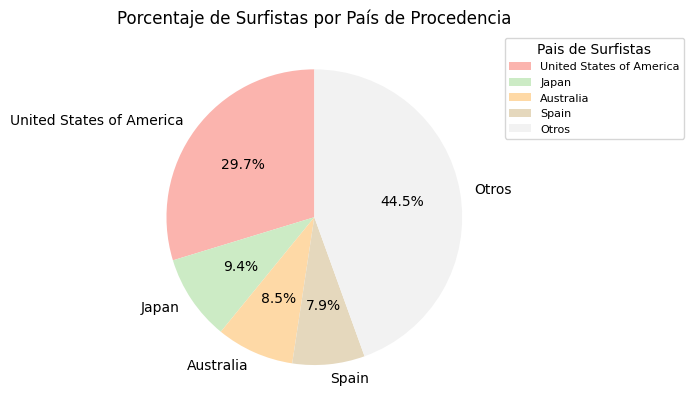

In [30]:
# Pie Chart con Pandas
ax = df_final.plot.pie( # Agarra el indice como etiquetas por defecto
    y='homename', 
    startangle=90,
    autopct='%1.1f%%',
    colormap='Pastel1' # Colores Pasteles. Muy agradable a la vista.
)

ax.set_ylabel('')
ax.legend(
    title='Pais de Surfistas',
    bbox_to_anchor=(1, 1),
    fontsize=8
)

ax.set_title('Porcentaje de Surfistas por País de Procedencia')